# 02 — Feature Engineering Diagnostics

Per v2 scheme §3.2: PACF + CCF lag selection.

**Methodology (run per-fold in the modeling pipeline, but run here on the full record for sanity-checking)**:
- PACF on the variable's own spatially-averaged series, up to lag 12
- CCF between the (predictor at lag k) and SPEI3 at time t, up to lag 12
- Selected lags = union of PACF-passing lags ∪ CCF-passing lags (threshold |·| > 0.20)
- Fast-response variables (Tmin, Tmax, Solar, Wind) tested at lag 1 only

Outputs saved to `results/figures/02_features/`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

from droughtmodel import data as ddata
from droughtmodel import features as dfeat
from droughtmodel.utils import save_figure

FIG_SUBDIR = '02_features'

data_config = ddata.load_config(ROOT / 'configs' / 'data.yaml')
feat_config = dfeat.load_features_config(ROOT / 'configs' / 'features.yaml')
datasets = ddata.load_all(data_config)

print('Long-memory vars:', feat_config['long_memory_vars'])
print('Fast-response vars:', feat_config['fast_response_vars'])
print('PACF threshold:', feat_config['pacf']['threshold'])
print('CCF threshold:', feat_config['ccf']['threshold'])

Long-memory vars: ['spei3', 'rzsm', 'enso', 'nao', 'mo', 'tcwv', 'precip', 'vpd']
Fast-response vars: ['tmin', 'tmax', 'solar', 'wind']
PACF threshold: 0.2
CCF threshold: 0.2


## PACF — long-memory variables (spatial mean)

Bars above the dashed threshold survive PACF selection.

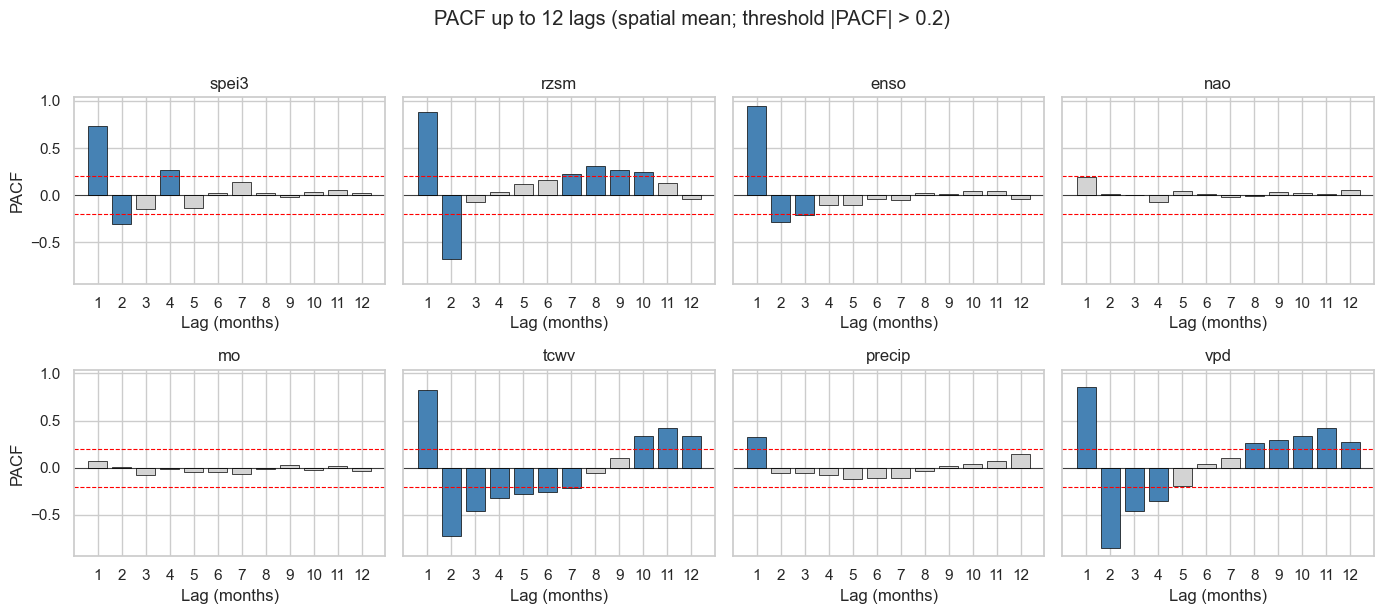

In [2]:
long_vars = feat_config['long_memory_vars']
n_lags = feat_config['pacf']['n_lags']
pacf_threshold = feat_config['pacf']['threshold']

n = len(long_vars)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows), sharey=True)
axes = axes.flatten()

pacf_results = {}
for i, var in enumerate(long_vars):
    da = dfeat.gather_predictor(var, datasets)
    series = dfeat.spatial_mean(da).values
    vals = dfeat.compute_pacf(series, n_lags=n_lags)
    pacf_results[var] = vals

    lags = np.arange(1, n_lags + 1)
    colors = ['steelblue' if abs(v) > pacf_threshold else 'lightgray' for v in vals]
    axes[i].bar(lags, vals, color=colors, edgecolor='black', linewidth=0.5)
    axes[i].axhline(pacf_threshold, color='red', linestyle='--', linewidth=0.8)
    axes[i].axhline(-pacf_threshold, color='red', linestyle='--', linewidth=0.8)
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].set_title(var)
    axes[i].set_xlabel('Lag (months)')
    axes[i].set_xticks(lags)
    if i % ncols == 0:
        axes[i].set_ylabel('PACF')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'PACF up to {n_lags} lags (spatial mean; threshold |PACF| > {pacf_threshold})', y=1.02)
plt.tight_layout()
save_figure(fig, 'pacf_long_memory_vars', subdir=FIG_SUBDIR)
plt.show()

## CCF — cross-correlation with SPEI3 (predictor leads target)

`CCF[k]` = corr( predictor at t−k , SPEI3 at t ). Strong positive bars at lag k mean the predictor at k months ago is informative for SPEI3 now.

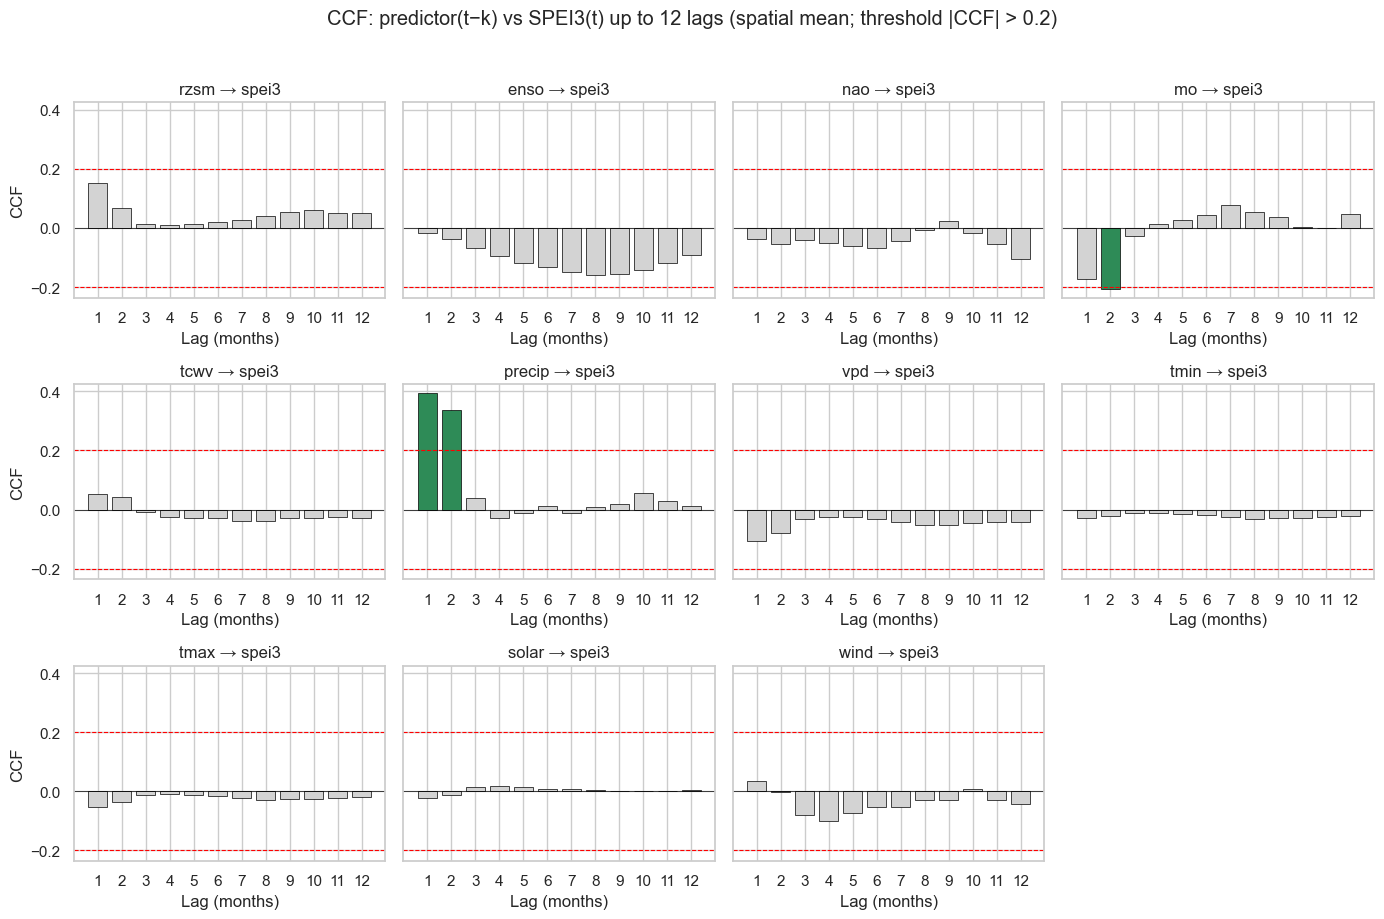

In [3]:
ccf_max = feat_config['ccf']['max_lag']
ccf_threshold = feat_config['ccf']['threshold']
target_series = dfeat.spatial_mean(dfeat.gather_predictor('spei3', datasets)).values

# Run CCF on every candidate predictor (long-memory + fast-response except spei3 itself).
ccf_vars = [v for v in long_vars + feat_config['fast_response_vars'] if v != 'spei3']

n = len(ccf_vars)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows), sharey=True)
axes = axes.flatten()

ccf_results = {}
for i, var in enumerate(ccf_vars):
    da = dfeat.gather_predictor(var, datasets)
    series = dfeat.spatial_mean(da).values
    vals = dfeat.compute_ccf(series, target_series, max_lag=ccf_max)
    ccf_results[var] = vals

    lags = np.arange(1, ccf_max + 1)
    colors = ['seagreen' if abs(v) > ccf_threshold else 'lightgray' for v in vals]
    axes[i].bar(lags, vals, color=colors, edgecolor='black', linewidth=0.5)
    axes[i].axhline(ccf_threshold, color='red', linestyle='--', linewidth=0.8)
    axes[i].axhline(-ccf_threshold, color='red', linestyle='--', linewidth=0.8)
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].set_title(f'{var} → spei3')
    axes[i].set_xlabel('Lag (months)')
    axes[i].set_xticks(lags)
    if i % ncols == 0:
        axes[i].set_ylabel('CCF')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'CCF: predictor(t−k) vs SPEI3(t) up to {ccf_max} lags (spatial mean; threshold |CCF| > {ccf_threshold})', y=1.02)
plt.tight_layout()
save_figure(fig, 'ccf_predictors_vs_spei3', subdir=FIG_SUBDIR)
plt.show()

## Lag selection — full-record summary

Lags that survive PACF ∪ CCF on the full 1950–2024 record. (Per-fold selection done in the modeling pipeline.)

In [4]:
selected_lags, diag = dfeat.select_lags_from_training(
    datasets,
    long_memory_vars=feat_config['long_memory_vars'],
    fast_response_vars=feat_config['fast_response_vars'],
    pacf_threshold=pacf_threshold,
    pacf_n_lags=n_lags,
    ccf_target=feat_config['ccf']['target'],
    ccf_threshold=ccf_threshold,
    ccf_max_lag=ccf_max,
)

summary = pd.DataFrame({
    'variable': list(selected_lags.keys()),
    'selected_lags': [selected_lags[v] for v in selected_lags],
    'n_lags_selected': [len(selected_lags[v]) for v in selected_lags],
})
summary

,variable,selected_lags,n_lags_selected
0,spei3,"[1, 2, 4]",3
1,rzsm,"[1, 2, 7, 8, 9, 10]",6
2,enso,"[1, 2, 3]",3
3,nao,[],0
4,mo,[2],1
5,tcwv,"[1, 2, 3, 4, 5, 6, 7, 10, 11, 12]",10
6,precip,"[1, 2]",2
7,vpd,"[1, 2, 3, 4, 8, 9, 10, 11, 12]",9
8,tmin,[1],1
9,tmax,[1],1


## Build a sample per-lead dataset (L = 3)

Inspect the assembled feature+target Dataset for one lead time.

In [5]:
lead = 3
ds_L3 = dfeat.build_dataset(
    datasets,
    lead=lead,
    contemporary=feat_config['contemporary_predictors'],
    lags=selected_lags,
    include_seasonal=feat_config['include_seasonal_encoding'],
    include_spatial=feat_config['include_spatial_encoding'],
)

print(f'Lead = {ds_L3.attrs["lead"]} month(s)')
print(f'Total feature variables: {len(ds_L3.data_vars) - 1}  (excludes "target")')
print(f'Time steps: {ds_L3.sizes["time"]}; Winter months: {int(ds_L3["winter_mask"].sum())}')
print()
for var in ds_L3.data_vars:
    print(f'  {var}: dims={tuple(ds_L3[var].dims)}, shape={tuple(ds_L3[var].shape)}')

Lead = 3 month(s)
Total feature variables: 55  (excludes "target")
Time steps: 900; Winter months: 300

  precip: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  tmin: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  tmax: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  pet: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  vpd: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  wind: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  solar: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  tcwv: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  rzsm: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  enso: dims=('time',), shape=(900,)
  nao: dims=('time',), shape=(900,)
  mo: dims=('time',), shape=(900,)
  spei3: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  spei3_lag1: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  spei3_lag2: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  spei3_lag4: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  rzsm_lag1: dims=('time', 

## Feature correlation heatmap (spatial mean)

Pairwise Pearson correlations between contemporary features (spatially-averaged for tractability). Flags multicollinearity that VIF / Lasso will need to handle later.

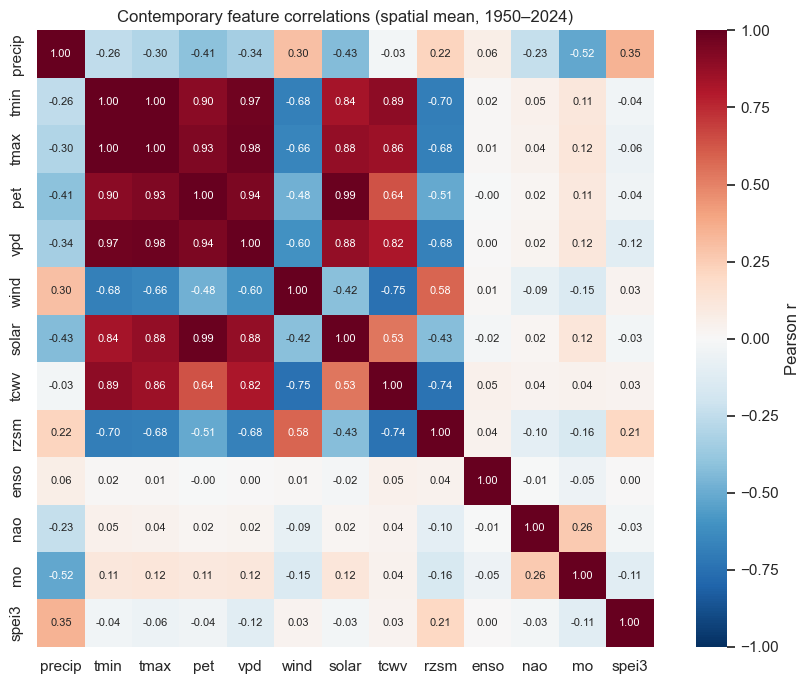

In [6]:
contemp = feat_config['contemporary_predictors']
df = pd.DataFrame({v: dfeat.spatial_mean(dfeat.gather_predictor(v, datasets)).values for v in contemp})
corr = df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Pearson r'}, ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Contemporary feature correlations (spatial mean, 1950\u20132024)')
plt.tight_layout()
save_figure(fig, 'feature_correlation_heatmap', subdir=FIG_SUBDIR)
plt.show()

## Seasonal encoding visualization

Sin/cos of month index gives the model a smooth annual cycle.

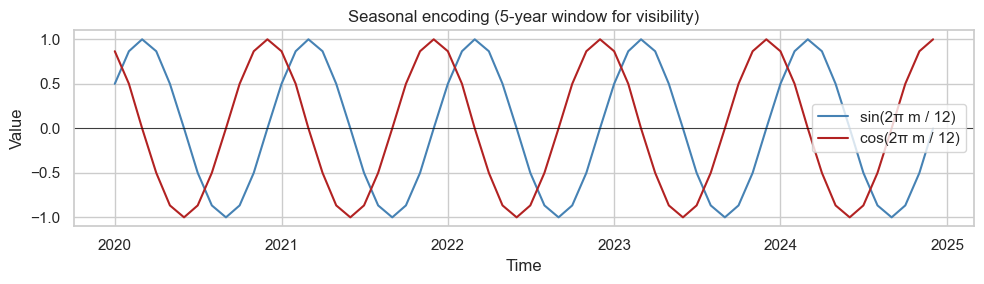

In [7]:
season = dfeat.add_seasonal_encoding(pd.date_range('2020-01', '2024-12', freq='MS'))

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(season['sin_month'].time, season['sin_month'].values, label='sin(2\u03c0 m / 12)', color='steelblue')
ax.plot(season['cos_month'].time, season['cos_month'].values, label='cos(2\u03c0 m / 12)', color='firebrick')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Seasonal encoding (5-year window for visibility)')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.legend()
plt.tight_layout()
save_figure(fig, 'seasonal_encoding', subdir=FIG_SUBDIR)
plt.show()

## Notes

- The lag selection shown here is **diagnostic only** — it uses the full 1950–2024 record. In the modeling pipeline (Phase 3) we run the same PACF/CCF procedure on each training fold only, to avoid leakage.
- Variables with **no surviving lags** (empty list) drop out of the lagged-feature set entirely (the contemporary feature remains).
- A predictor's **CCF peak lag** tells you the typical lead time of that teleconnection / driver. For Morocco we'd expect ENSO at 3–9 months, NAO at 1–6 months, MO at 1–3 months.
- The correlation heatmap will likely show **Tmin / Tmax / VPD / Solar tightly correlated**; VIF + Lasso (Phase 6) will prune redundancy for linear models. Tree models handle it natively.